In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics.pairwise import cosine_similarity

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
import os
os.listdir("../data")

['movie-recommendation-hackathon-2026']

In [4]:
os.listdir("../data/movie-recommendation-hackathon-2026")

['genome_scores.csv',
 'genome_tags.csv',
 'imdb_data.csv',
 'links.csv',
 'movies.csv',
 'sample_submission.csv',
 'tags.csv',
 'test.csv',
 'train.csv']

In [5]:
train = pd.read_csv("../data/movie-recommendation-hackathon-2026/train.csv")
test = pd.read_csv("../data/movie-recommendation-hackathon-2026/test.csv")
movies = pd.read_csv("../data/movie-recommendation-hackathon-2026/movies.csv")
imdb = pd.read_csv("../data/movie-recommendation-hackathon-2026/imdb_data.csv")
links = pd.read_csv("../data/movie-recommendation-hackathon-2026/links.csv")
tags = pd.read_csv("../data/movie-recommendation-hackathon-2026/tags.csv")

In [6]:
print("Dataset Shapes")
print("-" * 40)

print(f"Train dataset : {train.shape}")
print(f"Test dataset  : {test.shape}")
print(f"Movies dataset: {movies.shape}")
print(f"IMDb dataset  : {imdb.shape}")
print(f"Links dataset : {links.shape}")
print(f"Tags dataset  : {tags.shape}")

Dataset Shapes
----------------------------------------
Train dataset : (10000038, 4)
Test dataset  : (5000019, 2)
Movies dataset: (62423, 3)
IMDb dataset  : (27278, 6)
Links dataset : (62423, 3)
Tags dataset  : (1093360, 4)


In [7]:
for name, df in [
    ("Train", train),
    ("Test", test),
    ("Movies", movies),
    ("IMDb", imdb),
    ("Links", links),
    ("Tags", tags)
]:
    print(f"\n{name} Dataset")
    print("-" * 30)
    print(df.columns.tolist())


Train Dataset
------------------------------
['userId', 'movieId', 'rating', 'timestamp']

Test Dataset
------------------------------
['userId', 'movieId']

Movies Dataset
------------------------------
['movieId', 'title', 'genres']

IMDb Dataset
------------------------------
['movieId', 'title_cast', 'director', 'runtime', 'budget', 'plot_keywords']

Links Dataset
------------------------------
['movieId', 'imdbId', 'tmdbId']

Tags Dataset
------------------------------
['userId', 'movieId', 'tag', 'timestamp']


In [8]:
train.head()

,userId,movieId,rating,timestamp
0,5163,57669,4.0,1518349992
1,106343,5,4.5,1206238739
2,146790,5459,5.0,1076215539
3,106362,32296,2.0,1423042565
4,9041,366,3.0,833375837


In [9]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [10]:
imdb.head()

,movieId,title_cast,director,runtime,budget,plot_keywords
0,1,Tom Hanks|Tim Allen|Don Rickles|Jim Varney|Wal...,John Lasseter,81.0,"$30,000,000",toy|rivalry|cowboy|cgi animation
1,2,Robin Williams|Jonathan Hyde|Kirsten Dunst|Bra...,Jonathan Hensleigh,104.0,"$65,000,000",board game|adventurer|fight|game
2,3,Walter Matthau|Jack Lemmon|Sophia Loren|Ann-Ma...,Mark Steven Johnson,101.0,"$25,000,000",boat|lake|neighbor|rivalry
3,4,Whitney Houston|Angela Bassett|Loretta Devine|...,Terry McMillan,124.0,"$16,000,000",black american|husband wife relationship|betra...
4,5,Steve Martin|Diane Keaton|Martin Short|Kimberl...,Albert Hackett,106.0,"$30,000,000",fatherhood|doberman|dog|mansion


In [11]:
train["rating"].describe()

count    1.000004e+07
mean     3.533395e+00
std      1.061124e+00
min      5.000000e-01
25%      3.000000e+00
50%      3.500000e+00
75%      4.000000e+00
max      5.000000e+00
Name: rating, dtype: float64

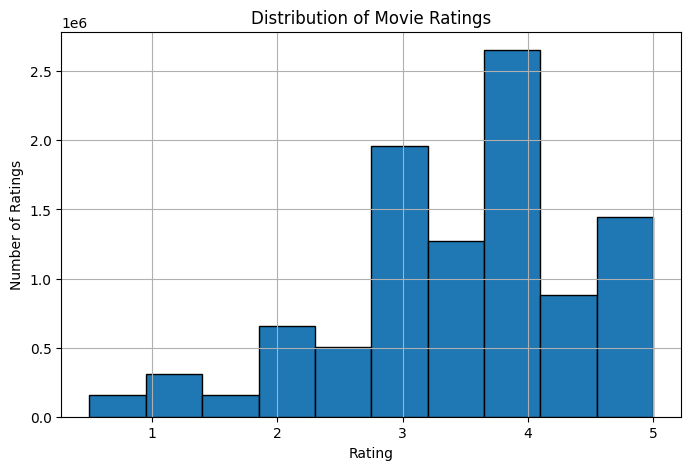

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

train["rating"].hist(bins=10, edgecolor="black")

plt.title("Distribution of Movie Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Ratings")

plt.show()

In [13]:
movie_rating_counts = (
    train.groupby("movieId")["rating"]
    .count()
    .sort_values(ascending=False)
)

In [14]:
movie_rating_counts.head(10)

movieId
318     32831
356     32383
296     31697
593     29444
2571    29014
260     27560
480     25518
527     24004
110     23722
2959    23536
Name: rating, dtype: int64

In [15]:
# Convert the Series into a DataFrame
movie_rating_counts = movie_rating_counts.reset_index()

# Rename the column
movie_rating_counts.columns = ["movieId", "rating_count"]

# Merge with the movies dataset
popular_movies = movie_rating_counts.merge(
    movies,
    on="movieId"
)

# Display the top 10
popular_movies.head(10)

,movieId,rating_count,title,genres
0,318,32831,"Shawshank Redemption, The (1994)",Crime|Drama
1,356,32383,Forrest Gump (1994),Comedy|Drama|Romance|War
2,296,31697,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller
3,593,29444,"Silence of the Lambs, The (1991)",Crime|Horror|Thriller
4,2571,29014,"Matrix, The (1999)",Action|Sci-Fi|Thriller
5,260,27560,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi
6,480,25518,Jurassic Park (1993),Action|Adventure|Sci-Fi|Thriller
7,527,24004,Schindler's List (1993),Drama|War
8,110,23722,Braveheart (1995),Action|Drama|War
9,2959,23536,Fight Club (1999),Action|Crime|Drama|Thriller
